## Self-Attention vs Cross-Attention in Decoders

This exercise demonstrates the difference between self-attention and cross-attention using pure PyTorch. Self-attention involves attending to tokens in the same sequence, while cross-attention allows the decoder to attend to the encoder's hidden states.
python
Copy
Edit


This function computes scaled dot-product attention by calculating attention scores, applying softmax to normalize them, and then multiplying the scores by the value vectors.

In [17]:
import torch
import torch.nn.functional as F


# Define a simple attention mechanism
def attention(query, key, value):
    # Scaled dot-product attention
    scores = torch.matmul(query, key.transpose(-2, -1)) / torch.sqrt(torch.tensor(key.size(-1), dtype=torch.float32))
    attn_weights = F.softmax(scores, dim=-1)
    output = torch.matmul(attn_weights, value)
    return output, attn_weights

In [18]:
# Example input sequences
encoder_output = torch.randn(5, 64)  # Encoder output (batch_size=1, seq_len=5, hidden_dim=64)
decoder_input = torch.randn(4, 64)  # Decoder input (batch_size=1, seq_len=4, hidden_dim=64)


query_weights = torch.nn.Linear(64, 64)
key_weights = torch.nn.Linear(64, 64)
value_weights = torch.nn.Linear(64, 64)

# Self-attention in the decoder
query = query_weights(decoder_input)
key = key_weights(decoder_input)
value = value_weights(decoder_input)
self_attention_output, self_attention_weights = attention(query, key, value)

# Cross-attention (decoder attends to encoder)
query = query_weights(decoder_input)
key = key_weights(encoder_output)
value = value_weights(encoder_output)
cross_attention_output, cross_attention_weights = attention(query, key, value)


In [19]:
print("Self-Attention Weights Shape:",
      self_attention_weights.shape)  # Shape: [decoder_seq_len, decoder_seq_len]
print("Cross-Attention Weights Shape:",
      cross_attention_weights.shape)  # Shape: [decoder_seq_len, encoder_seq_len]


Self-Attention Weights Shape: torch.Size([4, 4])
Cross-Attention Weights Shape: torch.Size([4, 5])


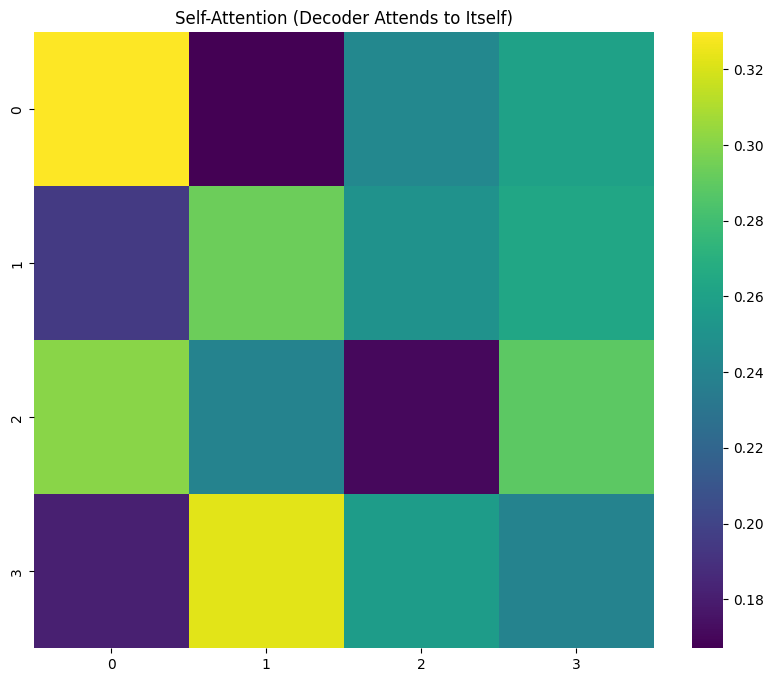

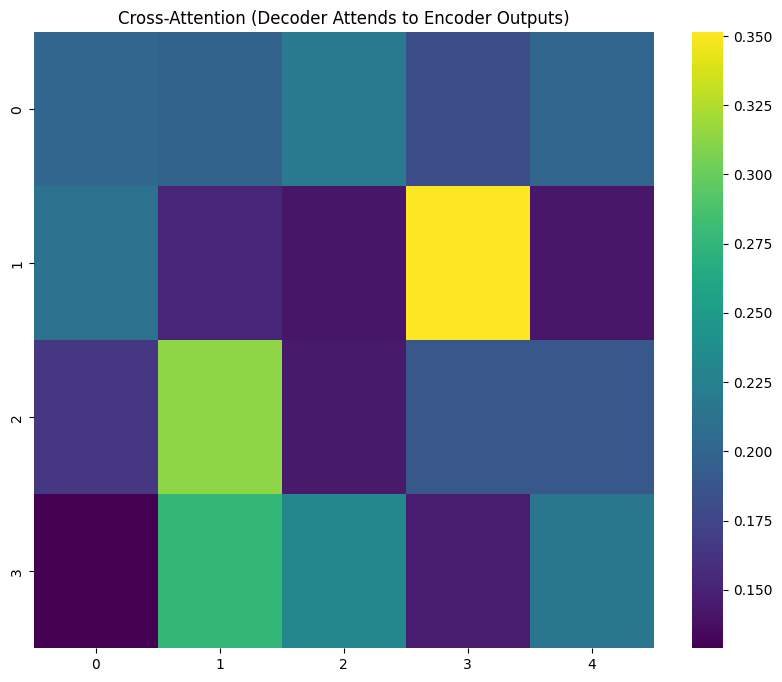

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize Self-Attention
plt.figure(figsize=(10, 8))
sns.heatmap(self_attention_weights.detach().numpy(), cmap="viridis")
plt.title("Self-Attention (Decoder Attends to Itself)")
plt.show()

# Visualize Cross-Attention
plt.figure(figsize=(10, 8))
sns.heatmap(cross_attention_weights.detach().numpy(), cmap="viridis")
plt.title("Cross-Attention (Decoder Attends to Encoder Outputs)")
plt.show()


## Masked Attention in Decoders
In this exercise, you'll manually compute masked attention in a decoder, where each token can only attend to previous tokens, simulating the autoregressive behavior of a language model.


This function implements masked scaled dot-product attention.
We first compute the attention scores, apply a mask to prevent attending to future tokens, and then apply softmax.

In [21]:
import torch
import torch.nn.functional as F


# Define masked attention mechanism
def masked_attention(query, key, value, mask):
    scores = torch.matmul(query, key.T) / torch.sqrt(torch.tensor(key.size(-1), dtype=torch.float32))

    # Apply the mask (set scores of future tokens to a very negative value)
    scores = scores.masked_fill(mask == 0, float('-inf'))

    # Apply softmax and compute attention output
    attn_weights = F.softmax(scores, dim=-1)
    output = torch.matmul(attn_weights, value)
    return output, attn_weights

We create a lower triangular mask using `torch.tril()` to prevent future tokens from being attended to.
The mask ensures that the model can only attend to tokens before or at the current position.

In [22]:
# Example decoder input
decoder_input = torch.randn(6, 64)  # (batch_size=1, seq_len=6, hidden_dim=64)

query_weights = torch.nn.Linear(64, 64)
key_weights = torch.nn.Linear(64, 64)
value_weights = torch.nn.Linear(64, 64)


# Create a triangular mask for autoregressive behavior
mask = torch.tril(torch.ones(decoder_input.shape[0], decoder_input.shape[0]))  # Lower triangular matrix

# Expand mask to match batch size and number of attention heads (assuming 1 head here)
mask = mask.unsqueeze(0)

# Compute masked attention
query = query_weights(decoder_input)
key = key_weights(decoder_input)
value = value_weights(decoder_input)
masked_attention_output, masked_attention_weights = masked_attention(query, key, value, mask)

In [23]:
torch.set_printoptions(linewidth=200)
print("Masked Attention Weights Shape:", masked_attention_weights.shape)
print("Masked Attention Weights Shape:\n", masked_attention_weights)

Masked Attention Weights Shape: torch.Size([1, 6, 6])
Masked Attention Weights Shape:
 tensor([[[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.3537, 0.6463, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.4893, 0.2952, 0.2155, 0.0000, 0.0000, 0.0000],
         [0.2800, 0.2098, 0.2506, 0.2596, 0.0000, 0.0000],
         [0.2953, 0.2648, 0.1630, 0.1282, 0.1487, 0.0000],
         [0.1191, 0.1763, 0.1604, 0.3119, 0.1227, 0.1096]]], grad_fn=<SoftmaxBackward0>)


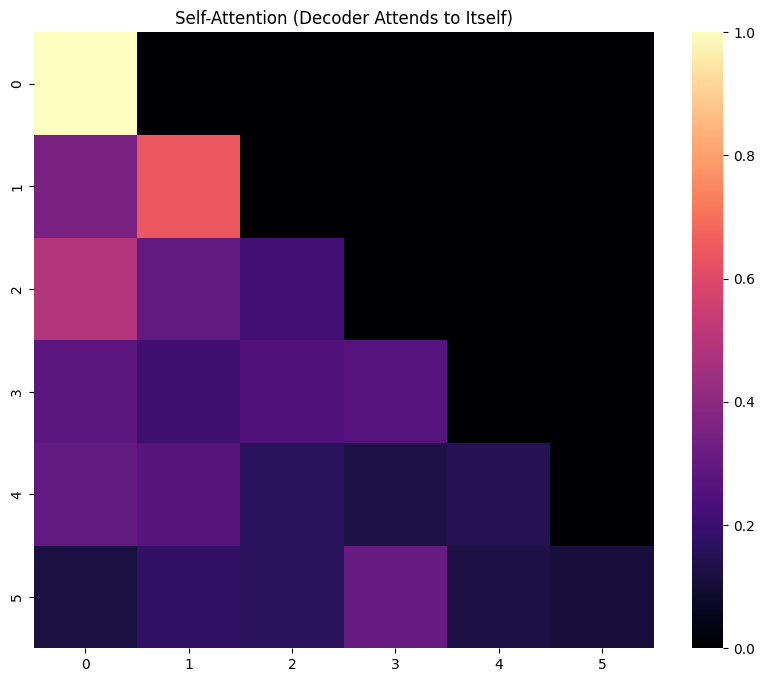

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize Masked Self-Attention
plt.figure(figsize=(10, 8))
sns.heatmap(masked_attention_weights[0].detach().numpy(), cmap="magma")
plt.title("Self-Attention (Decoder Attends to Itself)")
plt.show()



# Decoding Strategies: Greedy Search, Top-K Sampling, Nucleus Sampling (Top-p), and Beam Search

This exercise demonstrates various decoding strategies for generating text with GPT-2: Greedy Search, Top-K Sampling, Nucleus Sampling, and Beam Search.

Each strategy has its own approach to generating the next token in the sequence and affects the diversity and quality of the generated text.


In this cell, we load the pre-trained GPT-2 model and its corresponding tokenizer. These will be used to encode the input text and generate new text with different decoding strategies. We also define a maximum sequence length for the generated text.


In [25]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer

# Load pre-trained GPT-2 model and tokenizer
model_name = "gpt2"
max_length = 30
model = GPT2LMHeadModel.from_pretrained(model_name)
tokenizer = GPT2Tokenizer.from_pretrained(model_name)

/opt/homebrew/Caskroom/miniconda/base/envs/misc/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Cancellation requested; stopping current tasks.


KeyboardInterrupt: 

In [ ]:
model.eval()
tokenizer.pad_token = tokenizer.eos_token

In [ ]:
#DEFINE YOUR PROMPT
prompt = "After college graduation, I want to"

In [ ]:
input_ids = tokenizer.encode(prompt, return_tensors="pt")

This cell implements **Greedy Search**, which generates text by selecting the token with the highest probability at each time step. It is a deterministic approach, often leading to less diverse or repetitive text.

In [ ]:
print("\n--- Greedy Search ---")
output = model.generate(input_ids, max_length=max_length)
output = tokenizer.decode(output[0], skip_special_tokens=True)
output

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



--- Greedy Search ---


'After college graduation, I want to be a writer. I want to be a writer. I want to be a writer. I want to be a writer. I want to be a writer. I want to be a writer. I want to be a writer. I want to be a writer. I want to be a writer. I want to be a writer. I want to be a writer. I want to be a writer. I want to be a writer. I want to be a'

This cell implements **Top-K Sampling**, where at each step, the model samples from the top `k` tokens with the highest probabilities. The `temperature` parameter controls the randomness: higher temperatures increase randomness by flattening the probability distribution. Top-K Sampling encourages diversity while keeping the generated text sensible.

In [ ]:
print("\n--- Top-K Sampling ---")
top_k = 50
temperature = 1
output = model.generate(
    input_ids,
    max_length=max_length,
    do_sample=True,
    top_k=top_k,
    temperature=temperature
)
output = tokenizer.decode(output[0], skip_special_tokens=True)
output

In this cell, we use **Nucleus Sampling (Top-p Sampling)**, where the model samples from the smallest possible set of tokens whose cumulative probability exceeds `p` (here, 0.9). This method dynamically adjusts the token pool size based on the probability distribution, promoting more diversity while still maintaining coherent results.


In [ ]:
print("\n--- Nucleus Sampling ---")

top_p = 0.9
temperature = 1
output = model.generate(
    input_ids,
    max_length=max_length,
    do_sample=True,
    top_p=top_p,
    temperature=temperature
)

output = tokenizer.decode(output[0], skip_special_tokens=True)
output


This cell demonstrates **Beam Search**, a more sophisticated decoding strategy. Instead of choosing one token at each step, the model considers multiple candidate sequences (beams) and keeps the top `beam_size` sequences at each step. This ensures a better balance between exploration and the likelihood of the generated text. However, it can be computationally expensive.

In [ ]:

print("\n--- Beam Search ---")

beam_size = 5
output = model.generate(
    input_ids,
    max_length=max_length,
    num_beams=beam_size,
    early_stopping=True
)

output = tokenizer.decode(output[0], skip_special_tokens=True)
output

## Temperature Visualization
In this exercise you can see how temperature changes the output of the model.

In this cell, we initialize the GPT-2 model for text generation. We define `top_k` (the number of tokens considered at each step) and set the **temperature** parameter, which controls the randomness of the model's predictions. A higher temperature increases randomness by softening the probability distribution.


**Change the temperature to visualize the differences in the output distribution**

In [ ]:
import torch
from torch.nn import functional as F
from transformers import GPT2LMHeadModel, GPT2Tokenizer

# Load pre-trained GPT-2 model and tokenizer
model_name = "gpt2"
max_length = 30
model = GPT2LMHeadModel.from_pretrained(model_name)
top_k = 10
temperature = 1.8 ## Change this value to a value >= 0.
max_length = 100

Here, we provide a text prompt and generate text using the GPT-2 model with the defined temperature and top-k sampling.


In [ ]:
prompt = "After college graduation, I want to"
input_ids = tokenizer.encode(prompt, return_tensors="pt")


generation_output = model.generate(
    input_ids,
    max_length=max_length,
    do_sample=True,
    top_k=top_k,
    temperature=temperature,
    return_dict_in_generate=True, output_scores=True
)

logits_tensor = torch.stack(generation_output.scores, dim=1)  # Shape: [1, sequence_length, vocab_size]


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


In this cell, we compute the token probabilities for each step in the generated sequence by applying the softmax function to the logits. We then extract the top-k tokens and their probabilities, printing them for a single time step in the generated sequence.


In [ ]:
# Decode tokens and get related probabilities
for step_logits in logits_tensor[0]:  # Iterate over each timestep logits
    # Apply softmax to compute probabilities
    probs = F.softmax(step_logits, dim=-1)

    # Get the top tokens and their probabilities
    topk_probs, topk_indices = torch.topk(probs, k=10)  # Adjust 'k' as needed (e.g., top 10 tokens)

    # Decode token IDs into readable tokens
    topk_tokens = [tokenizer.decode([token_id]) for token_id in topk_indices]

    # Print tokens and their probabilities
    print("\nTokens and Probabilities:")
    for token, prob in zip(topk_tokens, topk_probs):
        print(f"Token: {token}, Probability: {prob.item()}")
    break



Tokens and Probabilities:
Token:  be, Probability: 0.27152949571609497
Token:  make, Probability: 0.09109196066856384
Token:  do, Probability: 0.08301867544651031
Token:  help, Probability: 0.08281686902046204
Token:  know, Probability: 0.08245373517274857
Token:  go, Probability: 0.07971533387899399
Token:  get, Probability: 0.07850820571184158
Token:  become, Probability: 0.07830780744552612
Token:  see, Probability: 0.07661880552768707
Token:  take, Probability: 0.07593907415866852


This cell decodes the generated sequence of token IDs back into human-readable text and displays the complete output generated by the GPT-2 model.


In [ ]:
output = tokenizer.decode(generation_output.sequences[0], skip_special_tokens=True)
output

'After college graduation, I want to get back to being the person who made me feel great in school, so to see that I got better is something that will keep going," he said.\n\nAnd as the days tick by I\'m ready to make a return to college with the confidence to succeed my parents would have told me to do so, he said of getting back in highschool and becoming successful.'

In this cell, we visualize the top-k token probabilities from the previous step using a bar chart. The tokens are displayed on the x-axis, and their corresponding probabilities are shown on the y-axis, allowing us to see how likely each token is based on the model's predictions.


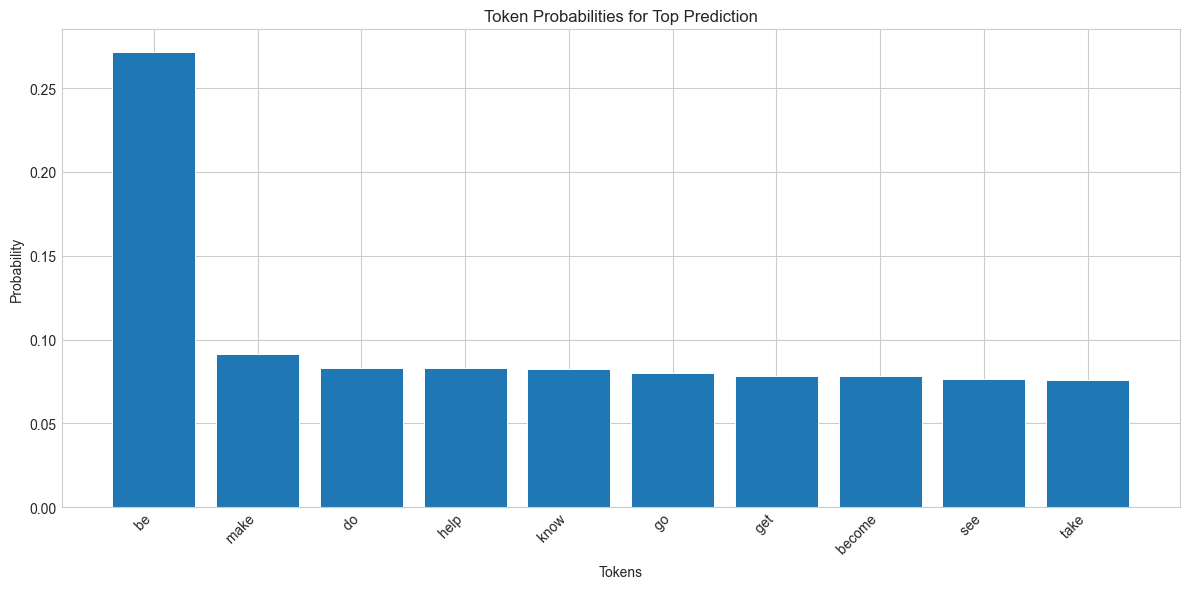

In [ ]:
import matplotlib.pyplot as plt

plt.style.use('_mpl-gallery')

# Make data
x = topk_tokens
y = topk_probs

# Plot
fig, ax = plt.subplots(figsize=(12, 6))  # Set width to 12 and height to 6
ax.bar(x, y, width=0.8, edgecolor="white", linewidth=0.7)

# Customize appearance
ax.set_title("Token Probabilities for Top Prediction")
ax.set_ylabel("Probability")
ax.set_xlabel("Tokens")
plt.xticks(rotation=45, ha='right', fontsize=10)  # Rotate and adjust x-axis token labels
plt.tight_layout()  # Adjust layout for better spacing

plt.show()